# Quick Analysis: Binary Target

Use this notebook to load a dataset, select numeric and categorical features, choose a binary target, and create descriptive and diagnostic charts.

## How It Works

1. Update the configuration in Section 0.
2. Run the notebook from top to bottom.
3. Review the data quality summary, charts, and feature ranking.

The target must contain exactly two non-missing classes. Set `POSITIVE_CLASS` to the event or outcome you want to study. The charts report the share of this positive class.


## 0. Configuration


In [1]:
# ============================================================
# CONFIGURATION — EDIT THIS SECTION
# ============================================================

USE_DEMO_DATA = True       # Set to False to load your own file
FILE_PATH = ""             # Example: r"C:\data\customers.xlsx" or "/content/data.csv"
SHEET_NAME = 0             # Excel sheet index or name
CSV_SEPARATOR = ","

# Example columns. Replace these with names from your dataset.
NUMERICAL = ["Age", "Income", "Spend", "Visits"]
CATEGORICAL = ["Region", "Channel", "Membership"]
TARGET = "Churn"
POSITIVE_CLASS = "Yes"     # Event or outcome class to study

# Limit the number of categories shown in charts
TOP_N_CATEGORIES = 12

# Convert data types when needed
TO_NUMERIC = []
TO_CATEGORICAL = []
TO_DATETIME = []


## 1. Import Libraries


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load Data


In [3]:
# Create demo data to preview the notebook

if USE_DEMO_DATA:
    rng = np.random.default_rng(42)
    n = 250

    region = rng.choice(
        ["North", "Central", "South"],
        n,
        p=[0.30, 0.25, 0.45]
    )

    channel = rng.choice(
        ["Online", "Store", "Partner"],
        n,
        p=[0.45, 0.40, 0.15]
    )

    membership = rng.choice(
        ["Basic", "Silver", "Gold"],
        n,
        p=[0.50, 0.30, 0.20]
    )

    age = rng.normal(35, 10, n).clip(18, 70)
    income = rng.normal(22_000_000, 7_000_000, n).clip(5_000_000)
    visits = rng.poisson(5, n) + 1

    spend = (
        income * 0.12
        + visits * 220_000
        + np.where(membership == "Gold", 1_500_000, 0)
        + np.where(channel == "Online", 600_000, 0)
        + rng.normal(0, 1_000_000, n)
    ).clip(200_000)

    churn = np.where(
        (visits <= 3) | (membership == "Basic"),
        rng.choice(["Yes", "No"], n, p=[0.55, 0.45]),
        rng.choice(["Yes", "No"], n, p=[0.20, 0.80])
    )

    df = pd.DataFrame({
        "Age": age.round(0),
        "Income": income.round(0),
        "Spend": spend.round(0),
        "Visits": visits,
        "Region": region,
        "Channel": channel,
        "Membership": membership,
        "Churn": churn
    })

    print("Demo data loaded:", df.shape)

Demo data loaded: (250, 8)


In [4]:
# Load a data file

if not USE_DEMO_DATA:
    file_to_load = FILE_PATH.strip()

    if not file_to_load:
        try:
            from google.colab import files
            uploaded = files.upload()
            file_to_load = next(iter(uploaded.keys()))
        except Exception:
            raise ValueError(
                "Enter FILE_PATH or run this notebook in Google Colab to upload a file."
            )

    suffix = Path(file_to_load).suffix.lower()

    if suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(
            file_to_load,
            sheet_name=SHEET_NAME
        )

    elif suffix == ".csv":
        df = pd.read_csv(
            file_to_load,
            sep=CSV_SEPARATOR
        )

    else:
        raise ValueError(
            "Supported file types are CSV, XLS, and XLSX."
        )

    print("Loaded:", file_to_load)
    print("Shape:", df.shape)

display(df.head())

,Age,Income,Spend,Visits,Region,Channel,Membership,Churn
0,34.00,"20,020,430.00","2,552,842.00",6,South,Store,Silver,No
1,46.00,"21,256,726.00","4,508,873.00",8,Central,Partner,Gold,No
2,18.00,"23,561,854.00","7,374,841.00",6,South,Store,Gold,No
3,20.00,"26,317,699.00","4,395,784.00",5,South,Online,Silver,No
4,26.00,"15,002,014.00","4,134,603.00",8,North,Online,Silver,No


## 3. Convert Data Types


In [5]:
# ============================================================
# Convert columns listed in TO_NUMERIC, TO_CATEGORICAL, and TO_DATETIME
# ============================================================

for col in TO_NUMERIC:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )
        print(f"Numeric: {col}")
    else:
        print(f"Column not found: {col}")

for col in TO_CATEGORICAL:
    if col in df.columns:
        df[col] = df[col].astype("category")
        print(f"Categorical: {col}")
    else:
        print(f"Column not found: {col}")

for col in TO_DATETIME:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )
        print(f"Datetime: {col}")
    else:
        print(f"Column not found: {col}")

## 4. Validate Configuration


In [6]:
# Validate the configuration and binary target
all_declared = set(NUMERICAL + CATEGORICAL + [TARGET])
missing_columns = sorted(col for col in all_declared if col not in df.columns)
if missing_columns:
    raise ValueError(f"Columns not found: {missing_columns}")
if TARGET in NUMERICAL or TARGET in CATEGORICAL:
    print("The target is also listed as a feature. It will be skipped in target comparison charts.")

target_values = df[TARGET].dropna().unique().tolist()
if len(target_values) != 2:
    raise ValueError(f"The target must have exactly 2 non-missing classes. Found {len(target_values)}: {target_values}")
if POSITIVE_CLASS not in target_values:
    raise ValueError(f"POSITIVE_CLASS={POSITIVE_CLASS!r} is not a target value. Available classes: {target_values}")

# Create an internal 0/1 indicator without changing the original target labels
positive = df[TARGET].eq(POSITIVE_CLASS)
class_counts = df[TARGET].value_counts(dropna=False)
print("Configuration is valid")
print("Shape:", df.shape)
print("NUMERICAL:", NUMERICAL)
print("CATEGORICAL:", CATEGORICAL)
print("TARGET:", TARGET, "| positive:", POSITIVE_CLASS)
display(pd.DataFrame({"count": class_counts, "share_%": (class_counts / len(df) * 100).round(2)}))


Configuration is valid
Shape: (250, 8)
NUMERICAL: ['Age', 'Income', 'Spend', 'Visits']
CATEGORICAL: ['Region', 'Channel', 'Membership']
TARGET: Churn | positive: Yes


,count,share_%
Churn,,
No,152,60.80
Yes,98,39.20


# 5. Descriptive Analysis

Run this section to create a distribution chart for each numeric feature and a frequency chart for each categorical feature.


DESCRIPTIVE ANALYSIS


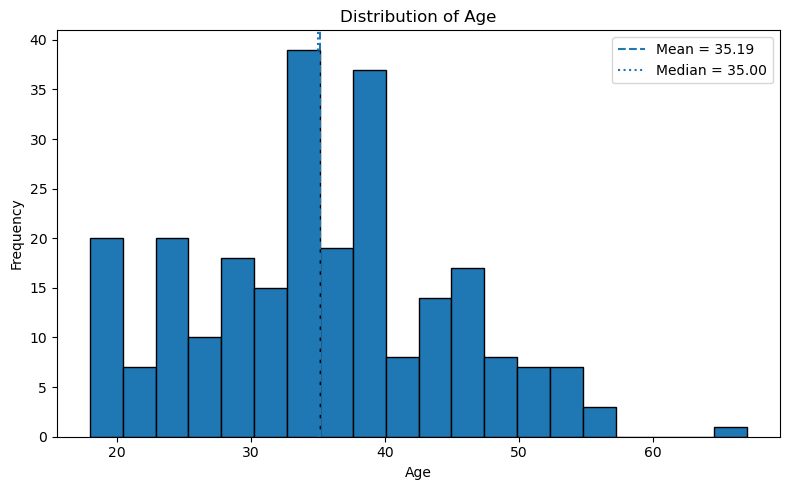

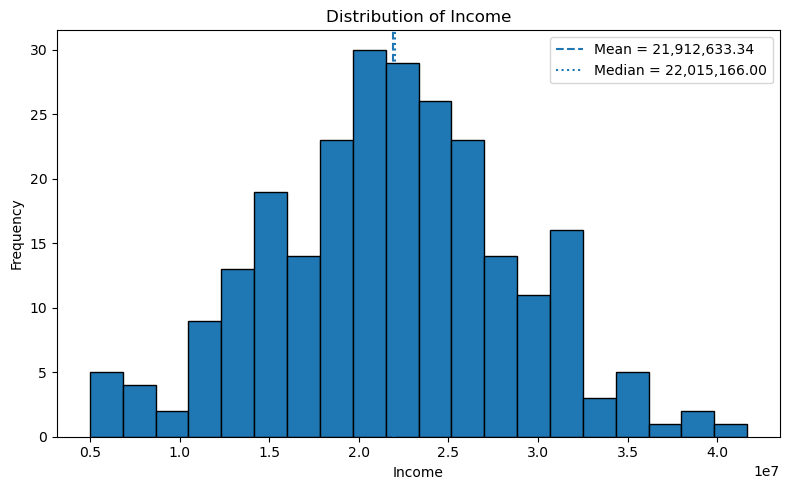

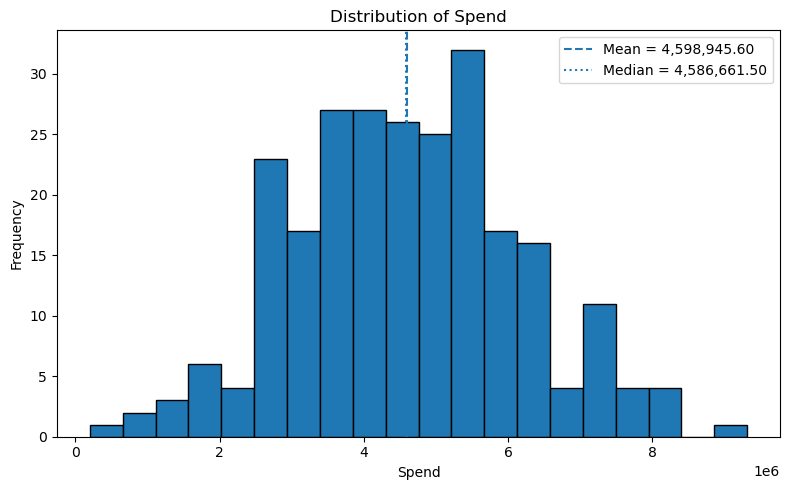

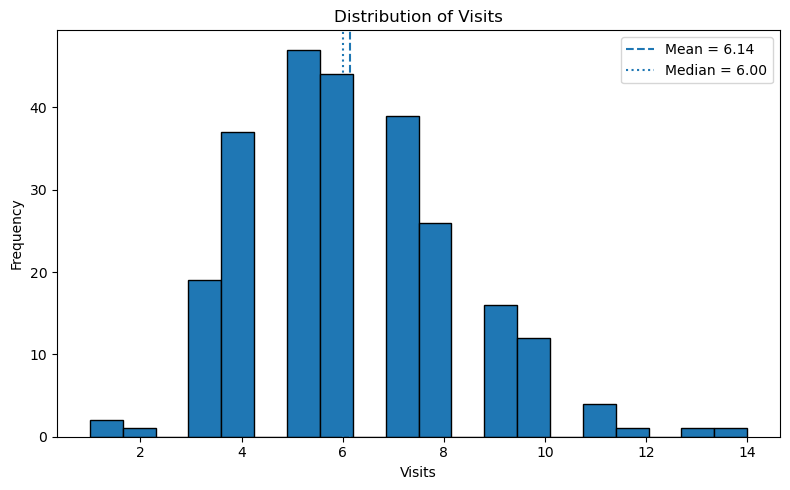

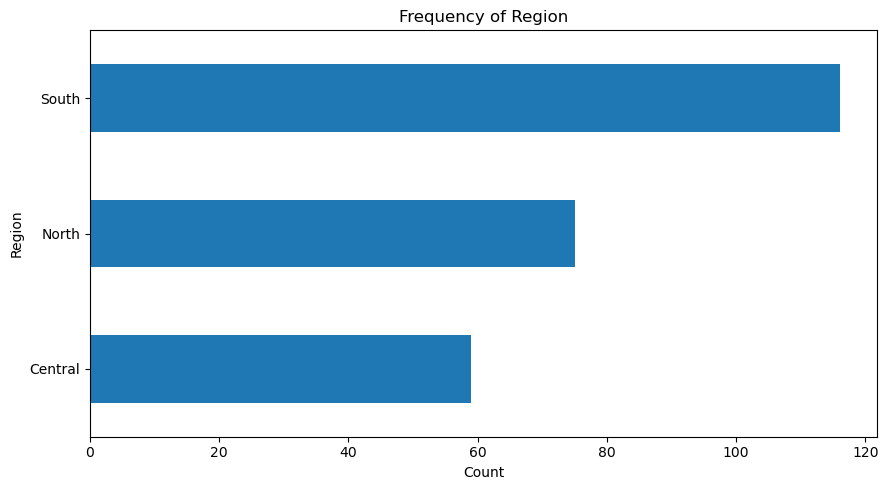

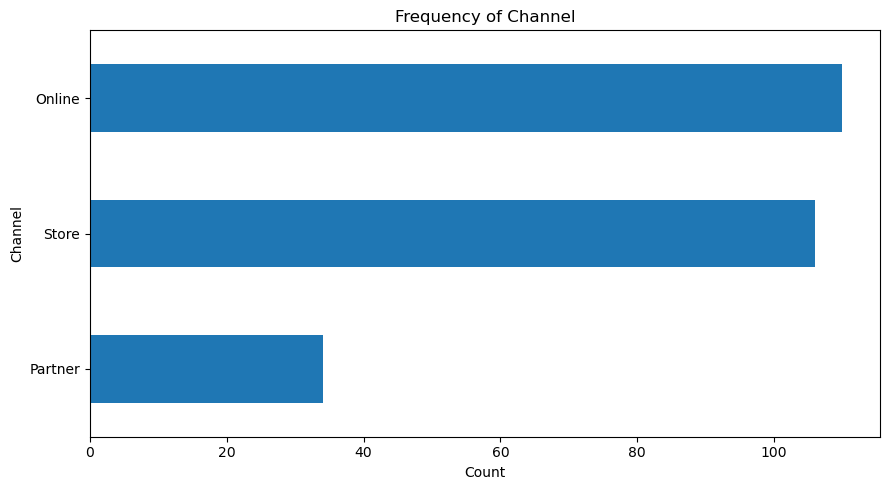

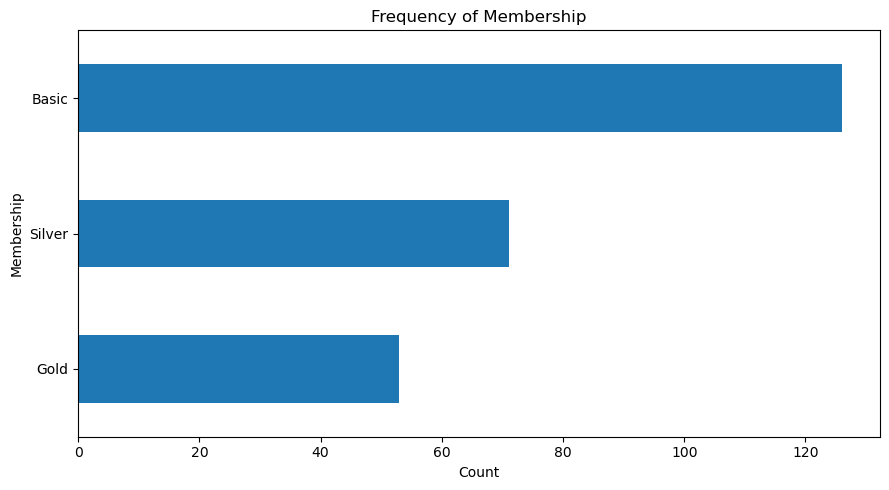

In [7]:
# ============================================================
# DESCRIPTIVE ANALYSIS — RUN ONCE
# ============================================================

print("=" * 70)
print("DESCRIPTIVE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. NUMERIC FEATURES — DISTRIBUTIONS AND HISTOGRAMS
# ------------------------------------------------------------

for col in NUMERICAL:

    if col not in df.columns:
        continue

    series = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna()

    if len(series) == 0:
        print(f"{col}: no valid numeric data.")
        continue

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        series,
        bins=20,
        edgecolor="black"
    )

    mean_value = series.mean()
    median_value = series.median()

    ax.axvline(
        mean_value,
        linestyle="--",
        label=f"Mean = {mean_value:,.2f}"
    )

    ax.axvline(
        median_value,
        linestyle=":",
        label=f"Median = {median_value:,.2f}"
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend()

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 2. CATEGORICAL FEATURES — BAR CHARTS
# ------------------------------------------------------------

for col in CATEGORICAL:

    if col not in df.columns:
        continue

    counts = (
        df[col]
        .fillna("Missing")
        .astype(str)
        .value_counts()
    )

    if len(counts) > TOP_N_CATEGORIES:
        print(
            f"{col}: {len(counts)} categories. Showing "
            f"the top {TOP_N_CATEGORIES}."
        )
        counts = counts.head(TOP_N_CATEGORIES)

    fig, ax = plt.subplots(figsize=(9, 5))

    counts.sort_values().plot(
        kind="barh",
        ax=ax
    )

    ax.set_title(f"Frequency of {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

# 6. Diagnostic Analysis

Use these charts to compare each feature with the binary target:

- Numeric features: compare distributions across the two target classes.
- Categorical features: compare positive rates across groups and review the target mix.
- Small groups can produce unstable rates. Check group sizes before interpreting extreme values.


DIAGNOSTIC ANALYSIS | positive = Yes


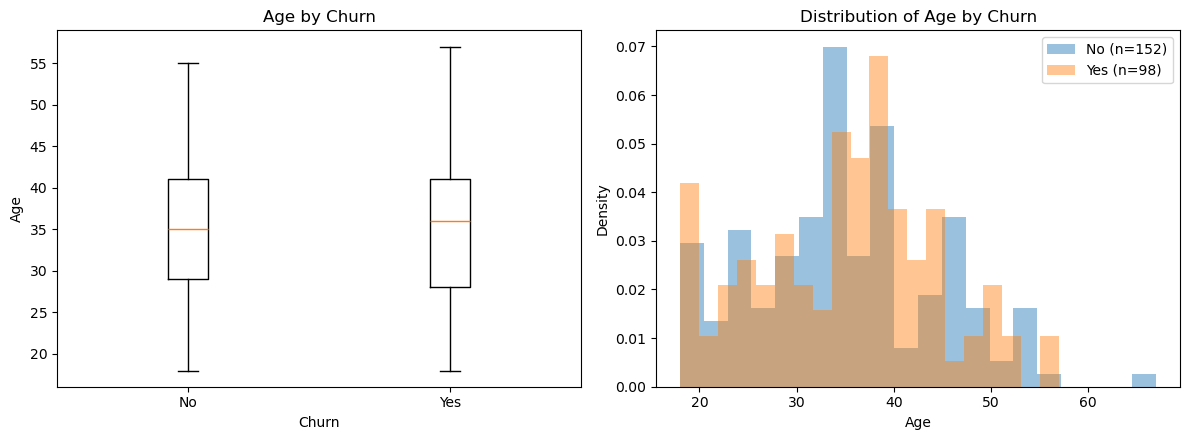

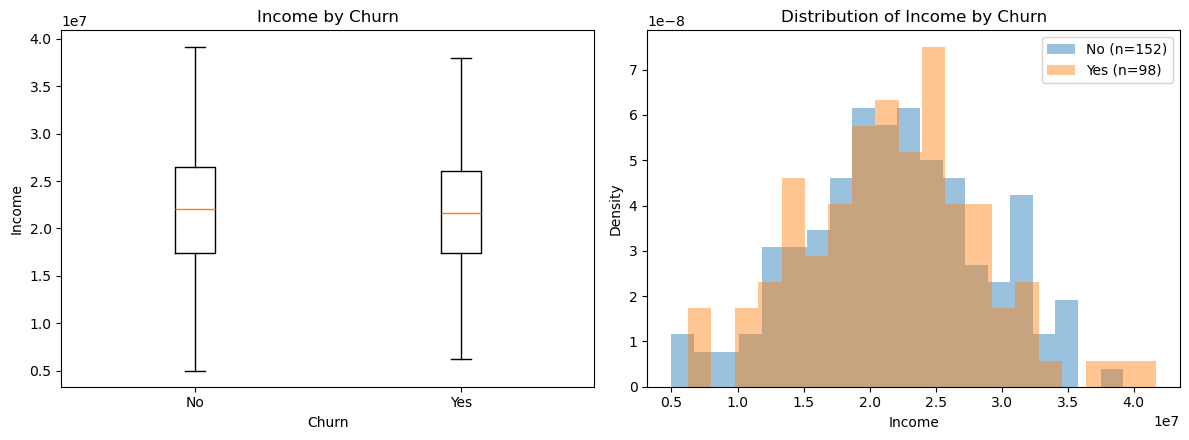

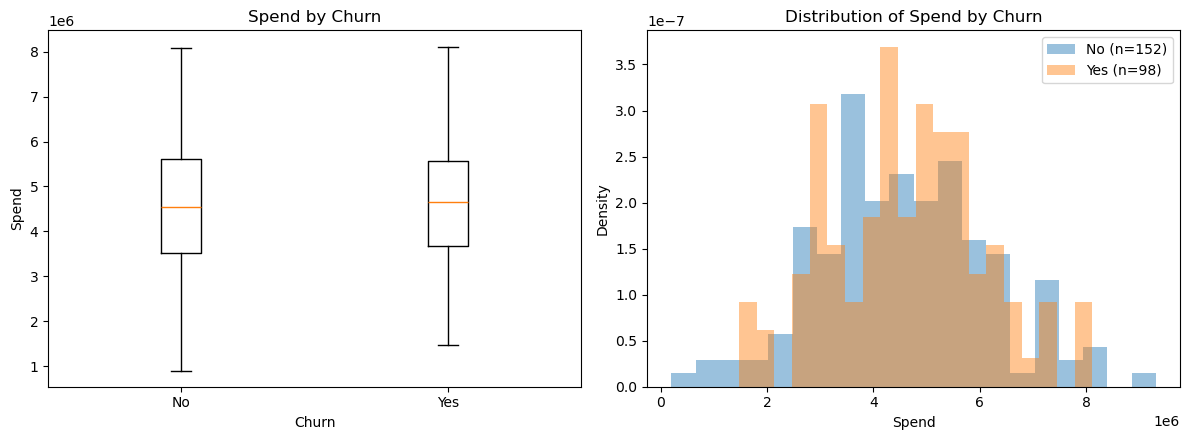

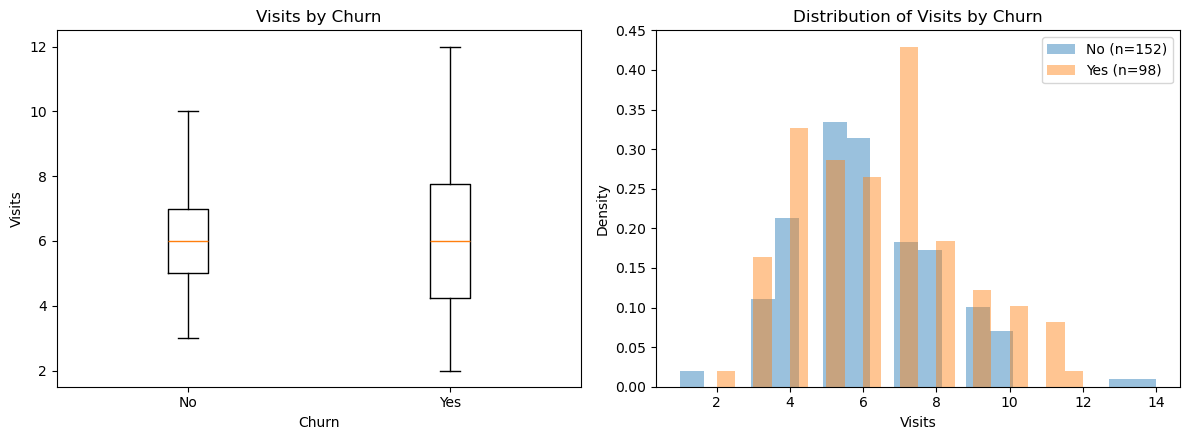

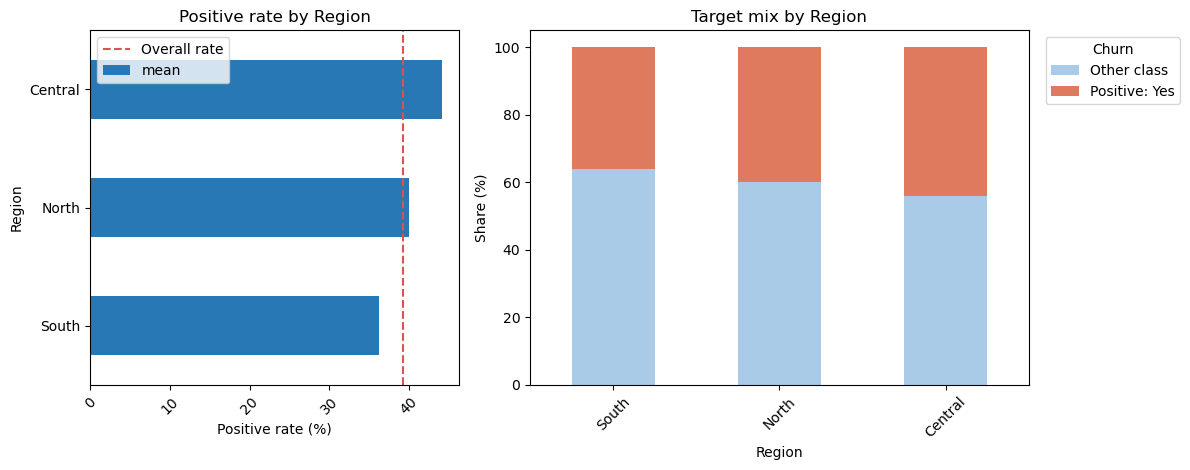

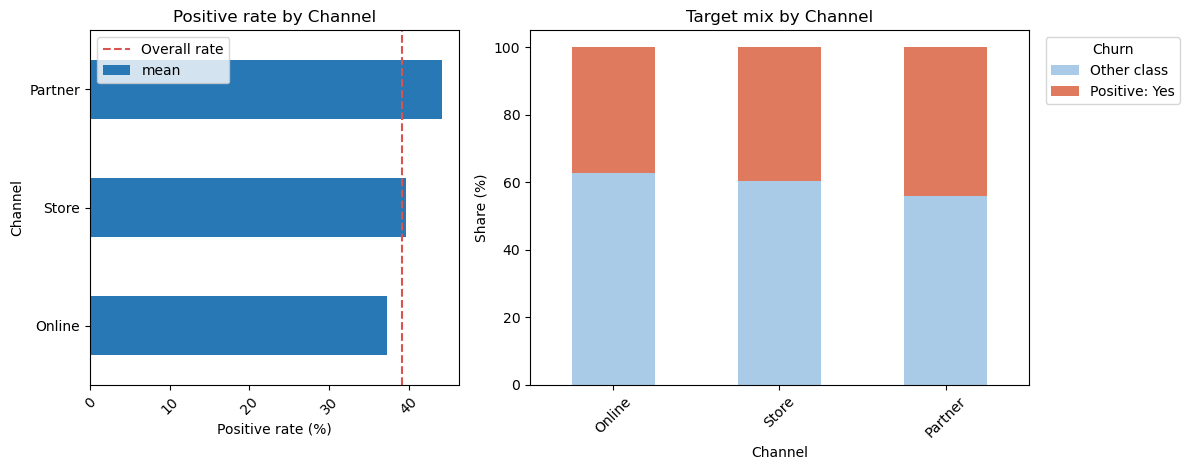

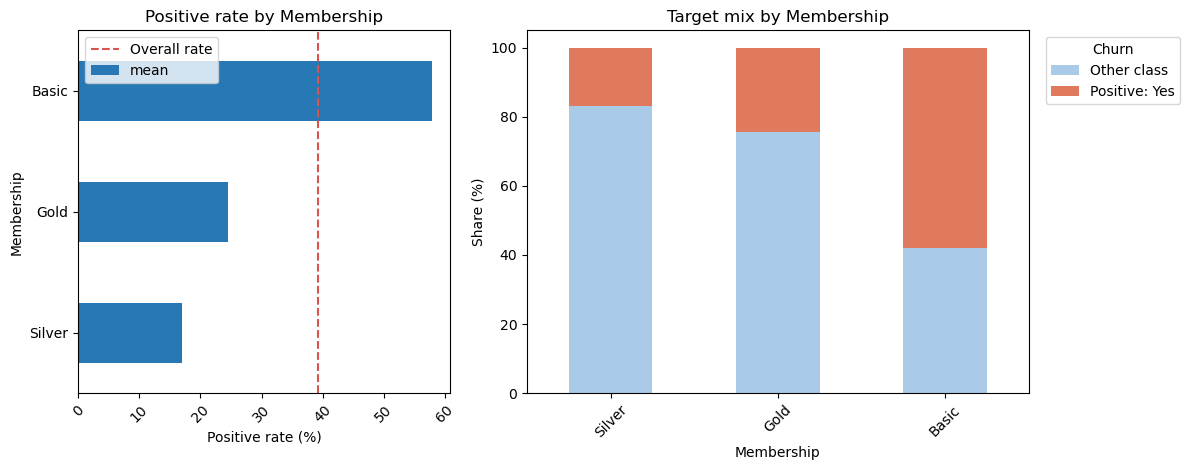

In [8]:
# Create diagnostic charts for the binary target
print("=" * 70, "\nDIAGNOSTIC ANALYSIS | positive =", POSITIVE_CLASS)

# Numeric features: compare distributions across target classes
for col in NUMERICAL:
    if col == TARGET:
        continue
    temp = pd.DataFrame({col: pd.to_numeric(df[col], errors="coerce"), "_target": df[TARGET]}).dropna()
    if temp.empty or temp[col].nunique() < 1:
        print(f"Skipping {col}: no valid numeric data.")
        continue
    groups = [temp.loc[temp["_target"].eq(cls), col].values for cls in target_values]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].boxplot(groups, labels=[str(v) for v in target_values], showfliers=False)
    axes[0].set(title=f"{col} by {TARGET}", xlabel=TARGET, ylabel=col)
    for cls in target_values:
        vals = temp.loc[temp["_target"].eq(cls), col]
        if len(vals):
            axes[1].hist(vals, bins=20, alpha=0.45, density=True, label=f"{cls} (n={len(vals)})")
    axes[1].set(title=f"Distribution of {col} by {TARGET}", xlabel=col, ylabel="Density")
    axes[1].legend()
    plt.tight_layout(); plt.show()

# Categorical features: compare positive rates and target shares by group
for col in CATEGORICAL:
    if col == TARGET:
        continue
    temp = pd.DataFrame({col: df[col].astype("object").where(df[col].notna(), "Missing"), "_positive": positive})
    top = temp[col].astype(str).value_counts().head(TOP_N_CATEGORIES).index
    temp[col] = temp[col].astype(str)
    temp = temp[temp[col].isin(top)]
    rates = temp.groupby(col, observed=False)['_positive'].agg(["mean", "size"]).sort_values("mean")
    cross = pd.crosstab(temp[col], temp["_positive"], normalize="index").reindex(rates.index) * 100
    cross = cross.rename(columns={False: "Other class", True: f"Positive: {POSITIVE_CLASS}"})
    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(rates) * 0.9), 4.8), gridspec_kw={"width_ratios": [1, 1.35]})
    rates["mean"].mul(100).plot(kind="barh", ax=axes[0], color="#2878B5")
    axes[0].axvline(positive.mean() * 100, color="#D9534F", linestyle="--", label="Overall rate")
    axes[0].set(title=f"Positive rate by {col}", xlabel="Positive rate (%)", ylabel=col)
    axes[0].legend()
    cross.plot(kind="bar", stacked=True, ax=axes[1], color=["#A9CBE8", "#E07A5F"])
    axes[1].set(title=f"Target mix by {col}", xlabel=col, ylabel="Share (%)")
    axes[1].legend(title=TARGET, bbox_to_anchor=(1.02, 1), loc="upper left")
    for ax in axes: ax.tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()


## 7. Quick Insight Tables

Review missing values, class balance, and simple feature-level signals to decide which variables to investigate further. These summaries are descriptive.


In [9]:
# QUICK INSIGHTS: missing values and univariate feature ranking
n_rows = len(df)
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique_n": df.nunique(dropna=True),
}).sort_values("missing_%", ascending=False)
print("Data quality (top missing columns)")
display(quality.head(20))
print(f"Positive rate ({POSITIVE_CLASS!r}): {positive.mean():.1%} | rows with missing target: {df[TARGET].isna().sum()}")

rows = []
base_rate = positive.mean()
for col in NUMERICAL:
    if col == TARGET: continue
    x = pd.to_numeric(df[col], errors="coerce")
    valid = x.notna() & df[TARGET].notna()
    pos = x[valid & positive].dropna(); neg = x[valid & ~positive].dropna()
    if len(pos) == 0 or len(neg) == 0: continue
    pooled = np.sqrt((pos.var(ddof=1) + neg.var(ddof=1)) / 2)
    effect = abs(pos.mean() - neg.mean()) / pooled if pooled and np.isfinite(pooled) else np.nan
    rows.append({"feature": col, "type": "numeric", "signal": effect, "signal_name": "|standardized mean difference|", "positive_rate_range_pp": np.nan, "min_group_n": min(len(pos), len(neg)), "missing_%": df[col].isna().mean()*100})
for col in CATEGORICAL:
    if col == TARGET: continue
    tmp = pd.DataFrame({"group": df[col].astype("object").where(df[col].notna(), "Missing"), "positive": positive}).dropna(subset=["positive"])
    stats = tmp.groupby("group", observed=False)["positive"].agg(["mean", "size"])
    # Exclude small groups (n < 5) from the rate-range summary.
    eligible = stats[stats["size"] >= 5]
    spread = (eligible["mean"].max() - eligible["mean"].min()) * 100 if len(eligible) >= 2 else np.nan
    rows.append({"feature": col, "type": "categorical", "signal": spread, "signal_name": "positive-rate range (pp; groups n>=5)", "positive_rate_range_pp": spread, "min_group_n": int(eligible["size"].min()) if len(eligible) else 0, "missing_%": df[col].isna().mean()*100})
ranking = pd.DataFrame(rows)
if not ranking.empty:
    ranking = ranking.sort_values("signal", ascending=False, na_position="last").reset_index(drop=True)
    display(ranking)
else:
    print("Not enough data to rank features.")


Data quality (top missing columns)


,dtype,missing_n,missing_%,unique_n
Age,float64,0,0.00,41
Income,float64,0,0.00,249
Spend,float64,0,0.00,250
Visits,int64,0,0.00,14
Region,object,0,0.00,3
Channel,object,0,0.00,3
Membership,object,0,0.00,3
Churn,object,0,0.00,2


Positive rate ('Yes'): 39.2% | rows with missing target: 0


,feature,type,signal,signal_name,positive_rate_range_pp,min_group_n,missing_%
0,Membership,categorical,41.04,positive-rate range (pp; groups n>=5),41.04,53,0.00
1,Region,categorical,7.86,positive-rate range (pp; groups n>=5),7.86,59,0.00
2,Channel,categorical,6.84,positive-rate range (pp; groups n>=5),6.84,34,0.00
3,Visits,numeric,0.12,|standardized mean difference|,NaN,98,0.00
4,Spend,numeric,0.03,|standardized mean difference|,NaN,98,0.00
5,Age,numeric,0.02,|standardized mean difference|,NaN,98,0.00
6,Income,numeric,0.02,|standardized mean difference|,NaN,98,0.00


# 8. How to Read the Charts

- Compare the medians and overlap in the boxplots. A larger difference and less overlap may indicate that a feature separates the two classes.
- Compare each categorical group's positive rate with the overall rate. Prioritize differences supported by larger group sizes.
- Rates from small groups are less stable. Use the sample sizes in the summary table when interpreting them.
- These charts show associations. They do not establish causation or replace model evaluation on validation data.


# 9. How to Use This Notebook

1. Set `USE_DEMO_DATA = False` and enter a file path in `FILE_PATH`. Leave the path empty to select a file in Google Colab.
2. Update `NUMERICAL`, `CATEGORICAL`, and `TARGET` with column names from your dataset.
3. Set `POSITIVE_CLASS` to one of the target values. The value and data type must match the dataset.
4. Include relevant explanatory features. Exclude identifiers and variables that would reveal the target after the prediction time.
5. Run all cells from top to bottom.


# 10. Notes

- Do not use customer IDs, transaction IDs, or variables created after the prediction time as features.
- Check missing values and class imbalance before interpreting the charts.
- Charts show up to `TOP_N_CATEGORIES` of the most frequent categories.
- A positive rate or feature-level signal is an exploratory result, not a causal conclusion or a model performance score.
